In [1]:
!pip install catboost
!pip install causalml
!pip install scikit-uplift
!pip install econml

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 30.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.1/95.1 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 81.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.9/76.9 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.8/56.8 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 269.8/269.8 kB 31.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.1/42.1 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 69.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 67.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 151.9/151.9 kB 15.3 MB/s eta 0:00:00
  Attempting uninstall: shap
    Found existing installation

In [71]:
import random, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as sps
import statsmodels.api as sm
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset
from torchvision import transforms
from torchvision.datasets import EuroSAT
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from tqdm.auto import tqdm
from joblib import Parallel, delayed
from typing import Any, Callable, Tuple
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklift.metrics import uplift_at_k, uplift_by_percentile, qini_auc_score, uplift_auc_score
from causalml.metrics import plot_qini, plot_gain
from sklift.models import TwoModels, SoloModel
from causalml.inference.meta import BaseXClassifier
from catboost import CatBoostRegressor, CatBoostClassifier

warnings.filterwarnings("ignore")
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DEVICE

device(type='cuda')

Выгрузим данные

In [4]:
from sklift.datasets import fetch_x5

data = fetch_x5()

Part 1: X5 train:   0%|          | 0.00/1.18M [00:00<?, ?iB/s]

Part 2: X5 clients:   0%|          | 0.00/7.64M [00:00<?, ?iB/s]

Part 3: X5 purchases:   0%|          | 0.00/670M [00:00<?, ?iB/s]

Теперь разделим

In [7]:
data_clients = data['data']['clients']

clients = data['data']['train']
treatment = data['treatment']
target = data['target']

data_train = pd.concat([clients, treatment, target], axis=1)
data_purchases = data['data']['purchases']

Посмотрим, как выглядят вообще наши датасеты.

In [8]:
data_clients.head()

,client_id,first_issue_date,first_redeem_date,age,gender
0,000012768d,2017-08-05 15:40:48,2018-01-04 19:30:07,45,U
1,000036f903,2017-04-10 13:54:23,2017-04-23 12:37:56,72,F
2,000048b7a6,2018-12-15 13:33:11,NaN,68,F
3,000073194a,2017-05-23 12:56:14,2017-11-24 11:18:01,60,F
4,00007c7133,2017-05-22 16:17:08,2018-12-31 17:17:33,67,U


In [13]:
data_train.head()

,client_id,treatment_flg,target
0,000012768d,0,1
1,000036f903,1,1
2,00010925a5,1,1
3,0001f552b0,1,1
4,00020e7b18,1,1


In [ ]:
data_purchases.head()

,client_id,transaction_id,transaction_datetime,regular_points_received,express_points_received,regular_points_spent,express_points_spent,purchase_sum,store_id,product_id,product_quantity,trn_sum_from_iss,trn_sum_from_red
0,000012768d,7e3e2e3984,2018-12-01 07:12:45,10.0,0.0,0.0,0.0,1007.0,54a4a11a29,9a80204f78,2.0,80.0,NaN
1,000012768d,7e3e2e3984,2018-12-01 07:12:45,10.0,0.0,0.0,0.0,1007.0,54a4a11a29,da89ebd374,1.0,65.0,NaN
2,000012768d,7e3e2e3984,2018-12-01 07:12:45,10.0,0.0,0.0,0.0,1007.0,54a4a11a29,0a95e1151d,1.0,24.0,NaN
3,000012768d,7e3e2e3984,2018-12-01 07:12:45,10.0,0.0,0.0,0.0,1007.0,54a4a11a29,4055b15e4a,2.0,50.0,NaN
4,000012768d,7e3e2e3984,2018-12-01 07:12:45,10.0,0.0,0.0,0.0,1007.0,54a4a11a29,a685f1916b,1.0,22.0,NaN


In [ ]:
data_purchases.columns

Index(['client_id', 'transaction_id', 'transaction_datetime',
       'regular_points_received', 'express_points_received',
       'regular_points_spent', 'express_points_spent', 'purchase_sum',
       'store_id', 'product_id', 'product_quantity', 'trn_sum_from_iss',
       'trn_sum_from_red'],
      dtype='object')

Теперь проведём EDA - то есть хотим понять вообще какие взаимосвязи есть между таргетом (то есть совершённой покупкой) и тритментом (то есть отправленным сообщением).

Тем самым мы в идеале мы хотим сгенерировать конфаундеры и ковариаты, используя данные в `data_clients` и `data_purchses`, чтоб впоследствии их подавать в модели.

Сначала сгенерируем основные признаки по клиентам, чтоб дальше уже это анализировать, генерировать будем из логики. Для начала активность.

`transactions_cnt` — количество транзакций

`unique_days` — число уникальных дней покупок

`unique_months` — число уникальных месяцев активности

`first_purchase` — дата первой покупки

`last_purchase` — дата последней покупки

Потом связанные с деньгами

`total_spent` — суммарные траты клиента

`mean_purchase` — средний чек

Теперь уже с продуктами

`unique_products` — число уникальных товаров

`unique_stores` — число уникальных магазинов



In [42]:
def preprocess_purchases(
    purchases: pd.DataFrame
) -> pd.DataFrame:

    p = purchases.copy()
    p['transaction_datetime'] = pd.to_datetime(
        p['transaction_datetime']
    )
    p['date'] = p['transaction_datetime'].dt.date
    p['month'] = p['transaction_datetime'].dt.month
    p['day_of_week'] = (
        p['transaction_datetime']
        .dt.dayofweek
    )
    p['hour'] = (
        p['transaction_datetime']
        .dt.hour
    )
    p['weekend'] = (
        p['day_of_week'] >= 5
    ).astype(int)

    p = p.sort_values(
        ['client_id', 'transaction_datetime']
    )

    return p



def build_basic_client_features(
    p: pd.DataFrame
) -> pd.DataFrame:
    client_features = (
        p.groupby('client_id')
        .agg(
            transactions_cnt=(
                'transaction_id',
                'count'
            ),

            unique_days=(
                'date',
                'nunique'
            ),

            unique_months=(
                'month',
                'nunique'
            ),
            total_spent=(
                'purchase_sum',
                'sum'
            ),
            mean_purchase=(
                'purchase_sum',
                'mean'
            ),
            unique_products=(
                'product_id',
                'nunique'
            ),
            unique_stores=(
                'store_id',
                'nunique'
            ),
            first_purchase=(
                'transaction_datetime',
                'min'
            ),
            last_purchase=(
                'transaction_datetime',
                'max'
            ),
            weekend_share=(
                'weekend',
                'mean'
            ),

            avg_hour=(
                'hour',
                'mean'
            )

        )
        .reset_index()
    )

    return client_features


def add_recency_features(
    client_features: pd.DataFrame,
    p: pd.DataFrame
) -> pd.DataFrame:

    max_date = (
        p['transaction_datetime']
        .max()
    )

    client_features['recency_days'] = (
        max_date
        - client_features['last_purchase']
    ).dt.days

    client_features['customer_lifetime_days'] = (
        client_features['last_purchase']
        - client_features['first_purchase']
    ).dt.days

    client_features = client_features.drop(
        columns=[
            'first_purchase',
            'last_purchase'
        ]
    )

    return client_features


def add_intensity_features(
    client_features: pd.DataFrame
) -> pd.DataFrame:

    client_features['transactions_per_day'] = (
        client_features['transactions_cnt']
        / (
            client_features[
                'customer_lifetime_days'
            ] + 1
        )
    )

    client_features['spent_per_day'] = (
        client_features['total_spent']
        / (
            client_features[
                'customer_lifetime_days'
            ] + 1
        )
    )

    return client_features

def build_basket_features(
    p: pd.DataFrame
) -> pd.DataFrame:

    products_per_txn = (
        p.groupby(
            ['client_id', 'transaction_id']
        )
        .agg(
            products_in_txn=(
                'product_id',
                'nunique'
            )
        )
        .reset_index()
    )

    basket_features = (
        products_per_txn
        .groupby('client_id')
        .agg(
            avg_products_per_txn=(
                'products_in_txn',
                'mean'
            )
        )
        .reset_index()
    )

    return basket_features

def build_interpurchase_features(
    p: pd.DataFrame
) -> pd.DataFrame:

    p = p.copy()

    p['prev_purchase'] = (
        p.groupby('client_id')
        ['transaction_datetime']
        .shift(1)
    )

    p['days_between'] = (
        p['transaction_datetime']
        - p['prev_purchase']
    ).dt.days

    interpurchase = (
        p.groupby('client_id')
        .agg(

            avg_days_between=(
                'days_between',
                'mean'
            ),

        )
        .reset_index()
    )

    return interpurchase


def build_favorite_store_feature(
    p: pd.DataFrame
) -> pd.DataFrame:

    favorite_store = (
        p.groupby(
            ['client_id', 'store_id']
        )
        .size()
        .reset_index(name='cnt')
    )

    favorite_store = (
        favorite_store
        .sort_values(
            ['client_id', 'cnt'],
            ascending=[True, False]
        )
        .drop_duplicates('client_id')
    )

    favorite_store = (
        favorite_store[
            ['client_id', 'store_id']
        ]
        .rename(
            columns={
                'store_id': 'favorite_store'
            }
        )
    )

    return favorite_store

def build_favorite_product_feature(
    p: pd.DataFrame
) -> pd.DataFrame:

    favorite_product = (
        p.groupby(
            ['client_id', 'product_id']
        )
        .size()
        .reset_index(name='cnt')
    )

    favorite_product = (
        favorite_product
        .sort_values(
            ['client_id', 'cnt'],
            ascending=[True, False]
        )
        .drop_duplicates('client_id')
    )

    favorite_product = (
        favorite_product[
            ['client_id', 'product_id']
        ]
        .rename(
            columns={
                'product_id': 'favorite_product'
            }
        )
    )

    return favorite_product

def add_rfm_features(
    client_features: pd.DataFrame
) -> pd.DataFrame:

    client_features['R_rank'] = pd.qcut(
        client_features['recency_days'],
        5,
        labels=False,
        duplicates='drop'
    )

    client_features['F_rank'] = pd.qcut(
        client_features['transactions_cnt'],
        5,
        labels=False,
        duplicates='drop'
    )

    client_features['M_rank'] = pd.qcut(
        client_features['total_spent'],
        5,
        labels=False,
        duplicates='drop'
    )

    return client_features

Теперь сам пайплайн для соединения этих всех функций. Это удобно, поскольку можно отдельно редактировать признаки, если они показывают низкое качество

In [43]:
def build_client_features(
    purchases: pd.DataFrame
) -> pd.DataFrame:

    p = preprocess_purchases(purchases)

    client_features = build_basic_client_features(p)
    client_features = add_recency_features(client_features, p)
    client_features = add_intensity_features(client_features)

    basket_features = build_basket_features(p)
    client_features = client_features.merge(basket_features, on='client_id', how='left')

    interpurchase_features = build_interpurchase_features(p)
    client_features = client_features.merge(interpurchase_features, on='client_id', how='left')

    favorite_store = build_favorite_store_feature(p)
    client_features = client_features.merge(favorite_store, on='client_id', how='left')

    favorite_product = build_favorite_product_feature(p)
    client_features = client_features.merge(favorite_product, on='client_id', how='left')

    client_features = add_rfm_features(client_features)

    return client_features

Применим

In [44]:
client_features = build_client_features(data_purchases)
client_features.head()

,client_id,transactions_cnt,unique_days,unique_months,total_spent,mean_purchase,unique_products,unique_stores,weekend_share,avg_hour,...,customer_lifetime_days,transactions_per_day,spent_per_day,avg_products_per_txn,avg_days_between,favorite_store,favorite_product,R_rank,F_rank,M_rank
0,000012768d,52,4,2,40809.00,784.788462,46,3,0.576923,9.057692,...,103,0.500000,392.394231,13.000000,2.019608,017c89b915,057ea8df98,2,1,2
1,000036f903,162,32,5,58765.00,362.746914,96,5,0.283951,10.006173,...,108,1.486239,539.128440,5.062500,0.590062,6381a55c22,449e431b58,0,3,2
2,000048b7a6,56,8,4,29724.00,530.785714,44,2,0.446429,9.785714,...,86,0.643678,341.655172,7.000000,1.527273,1a01e2a7d8,13f3112f7c,2,1,1
3,000073194a,82,17,5,62719.92,764.877073,68,1,0.414634,9.817073,...,110,0.738739,565.044324,4.823529,1.271605,9e8fcd116d,212f305c8b,1,2,3
4,00007c7133,83,10,5,53998.72,650.586988,64,2,0.373494,12.975904,...,100,0.821782,534.640792,7.545455,1.170732,01ec6c98d7,53fc95e177,4,2,2


Теперь проведём анализ - хотим понять распределение ключевых признаков, пока что выделим численные и категориальные признаки

In [45]:
numeric_cols = client_features.select_dtypes(include=np.number).columns.tolist()
categorical_cols = client_features.select_dtypes(exclude=np.number).columns.tolist()

Теперь уже посмотрим на пропуски, это может быть важно в некоторых категориях

In [46]:
missing = client_features.isna().mean().sort_values(ascending=False)
missing

,0
avg_days_between,0.001907
transactions_cnt,0.000000
unique_days,0.000000
unique_months,0.000000
client_id,0.000000
total_spent,0.000000
mean_purchase,0.000000
unique_stores,0.000000
unique_products,0.000000
avg_hour,0.000000


В целом, ситуация более чем контролируемая, поэтому переходим к гистограммам - хотим понять есть ли смещённость распределений\выбросы. Если есть какие-то большие хвосты, то может быть полезным логарифмирование или удаление выбросов.

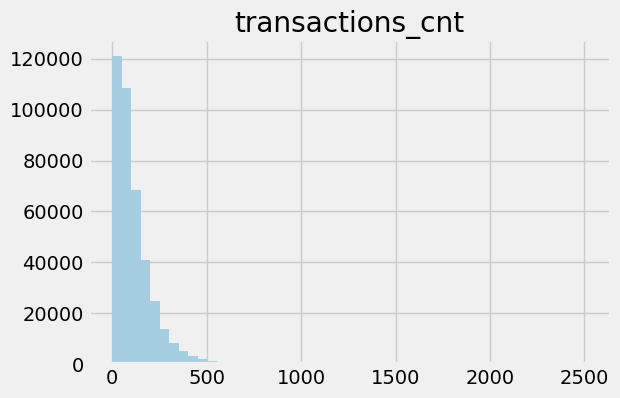

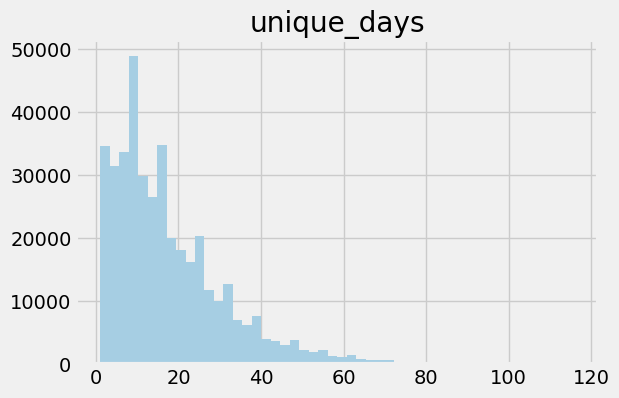

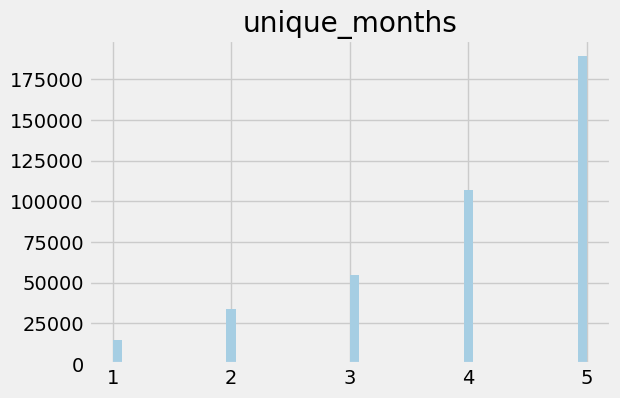

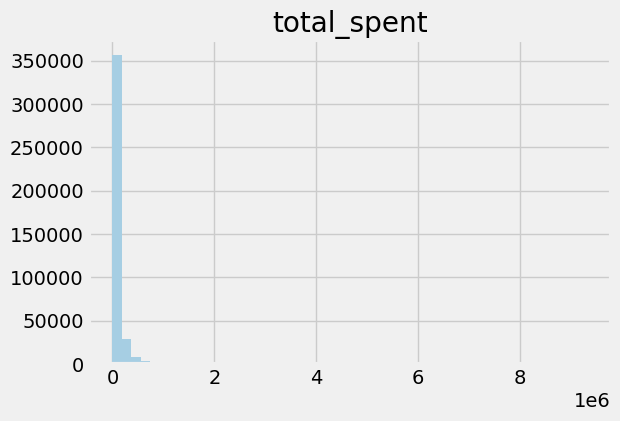

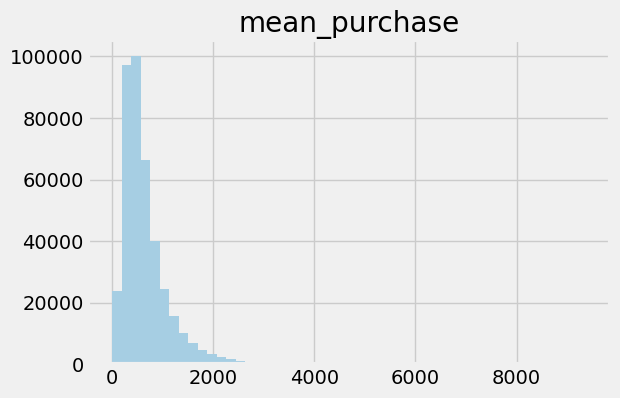

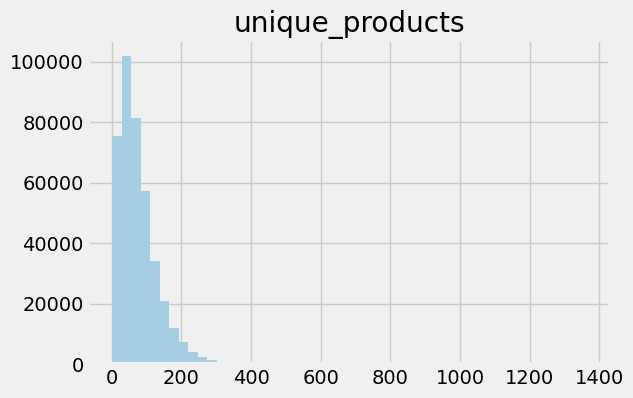

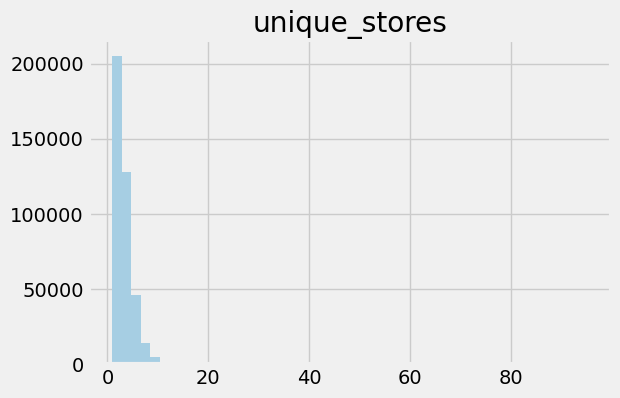

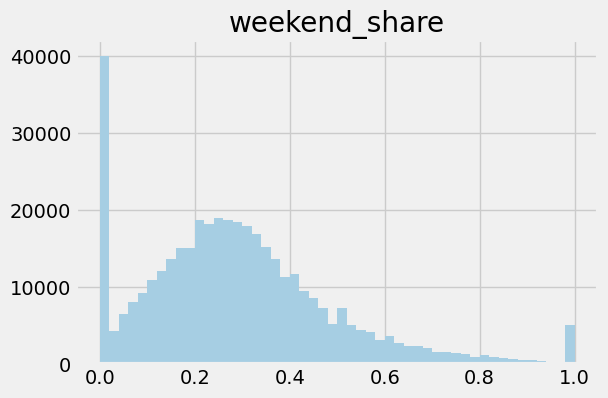

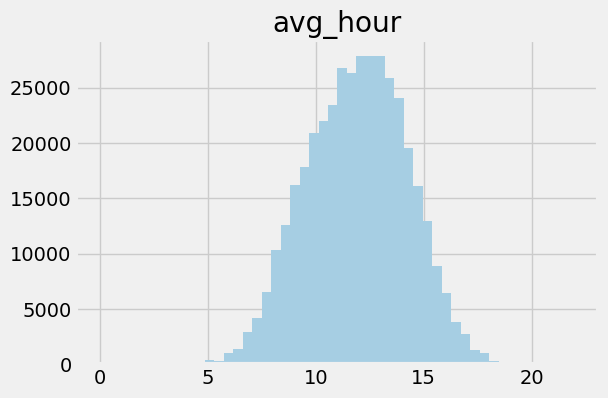

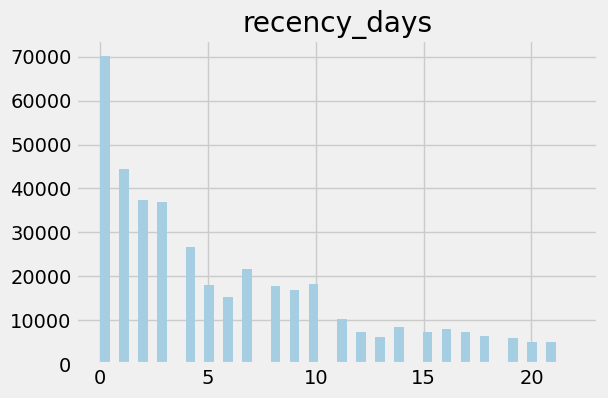

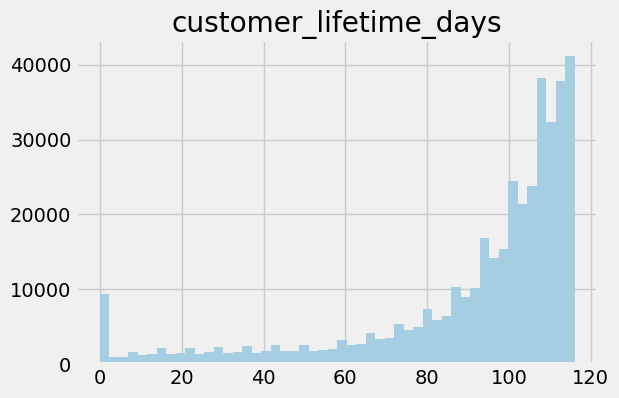

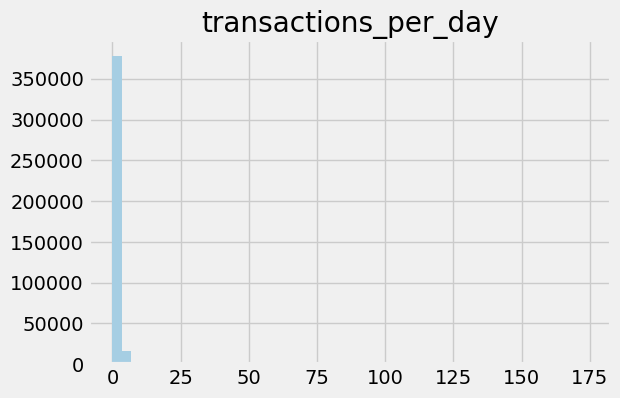

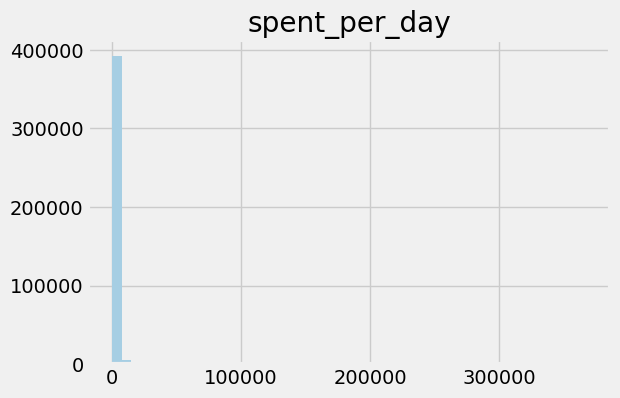

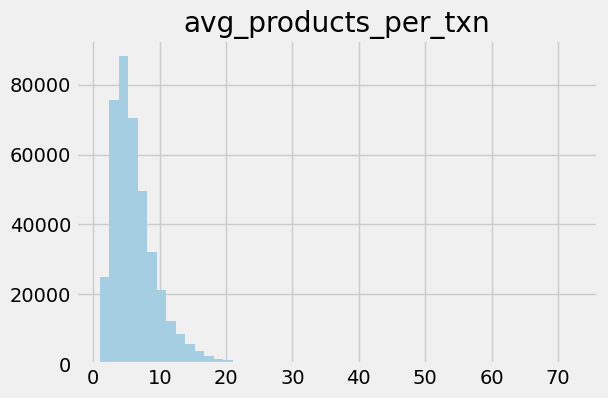

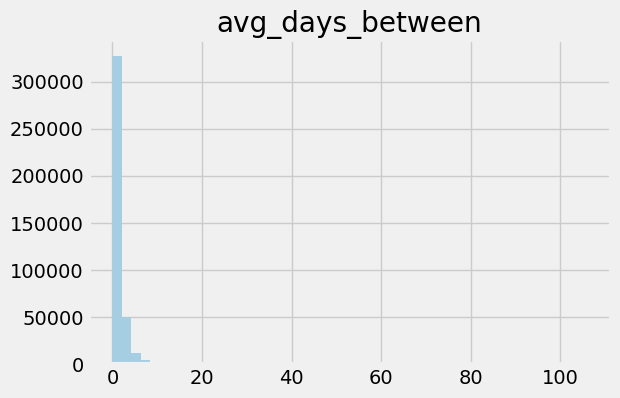

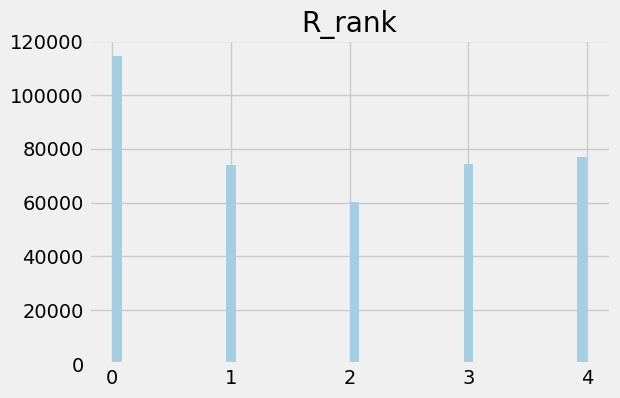

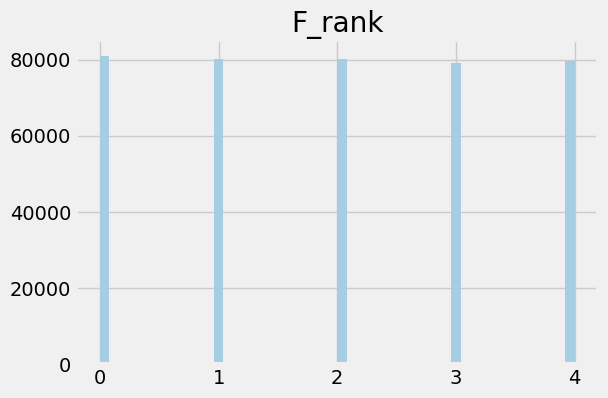

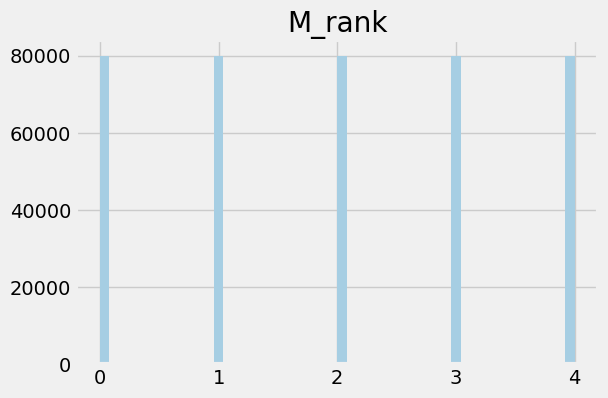

In [47]:
for col in numeric_cols:
    plt.figure(figsize=(6, 4))
    client_features[col].hist(bins=50)
    plt.title(col)
    plt.show()

В целом можно явно увидеть, что такие колонки, как `total_spent`, `transaction_cnt`, `mean_purchase`, `unique_products`, `unique_stores`, `transactions_per_day`, `spent_per_day`, `avg_days_between`, `avg_products_per_txn` очень сильно смещены влево, гистограммы состоят всего из нескольких видимых бинов - это значит, что здесь очень много выбросов, поэтому нужно провести их удаление. Только в uplift-моделировании грамотное удаление - это `winsorisation` - то есть обрезка значений, а не напрямую удаление, так как это может нарушить взаимосвязи в данных.



In [48]:
# признаки
winsor_cols = [
    'total_spent',
    'transactions_cnt',
    'mean_purchase',
    'unique_products',
    'unique_stores',
    'transactions_per_day',
    'spent_per_day',
    'avg_days_between',
    'avg_products_per_txn'
]

client_features_winsor = (
    client_features.copy()
)

winsor_thresholds = {}
for col in winsor_cols:
    upper = client_features_winsor[col].quantile(0.99)
    winsor_thresholds[col] = upper
    client_features_winsor[col] = np.clip(client_features_winsor[col], None, upper)

Теперь заново посмотрим на гистограммы для этих признаков

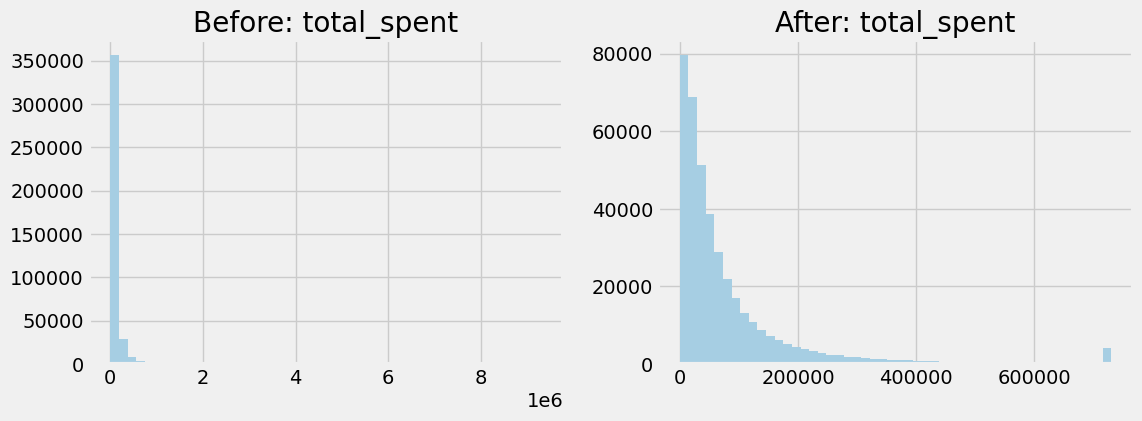

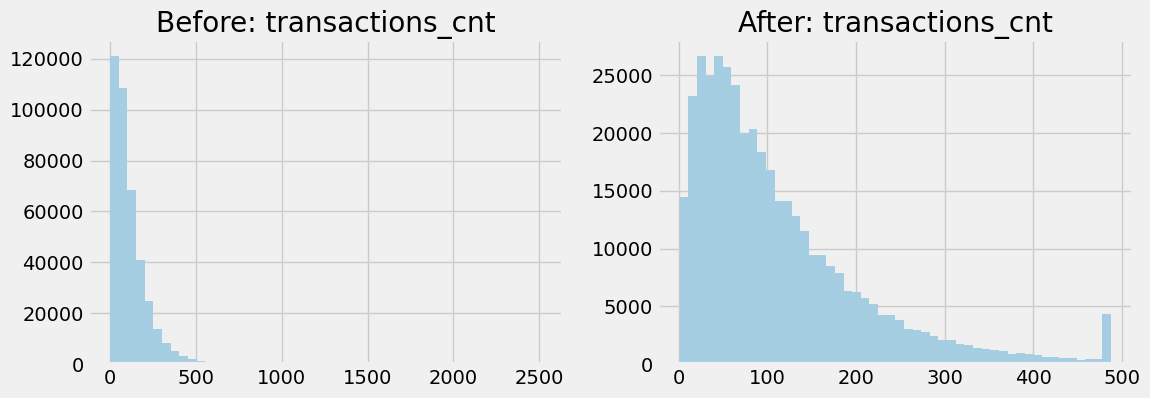

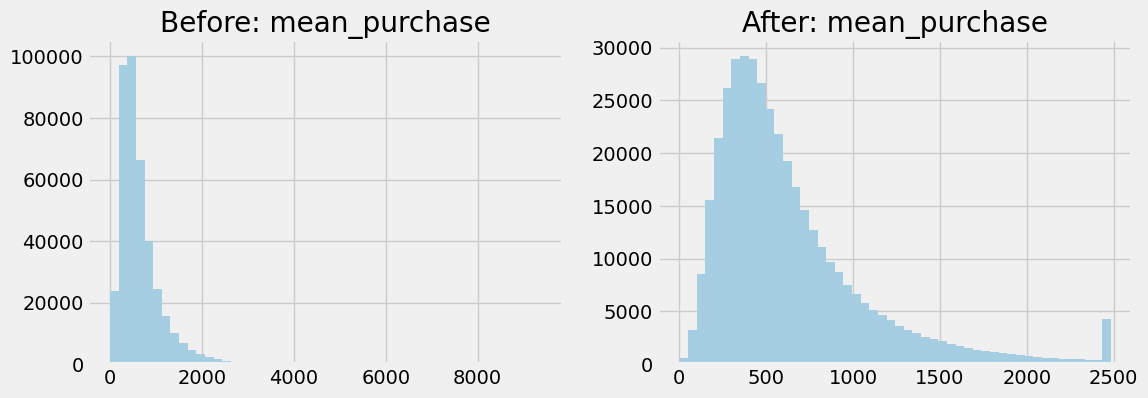

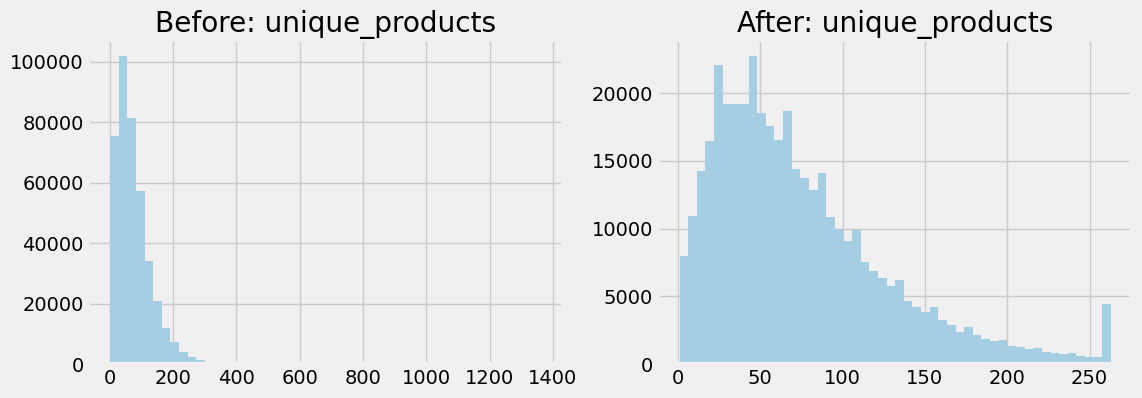

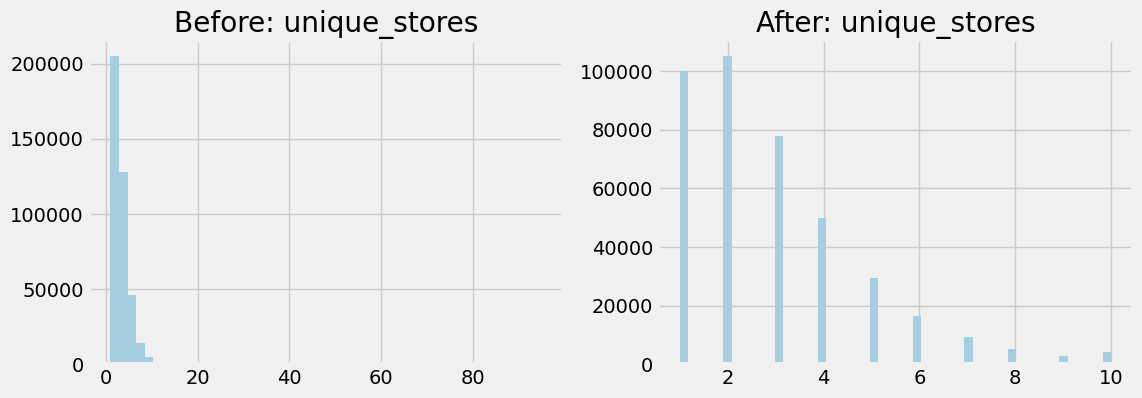

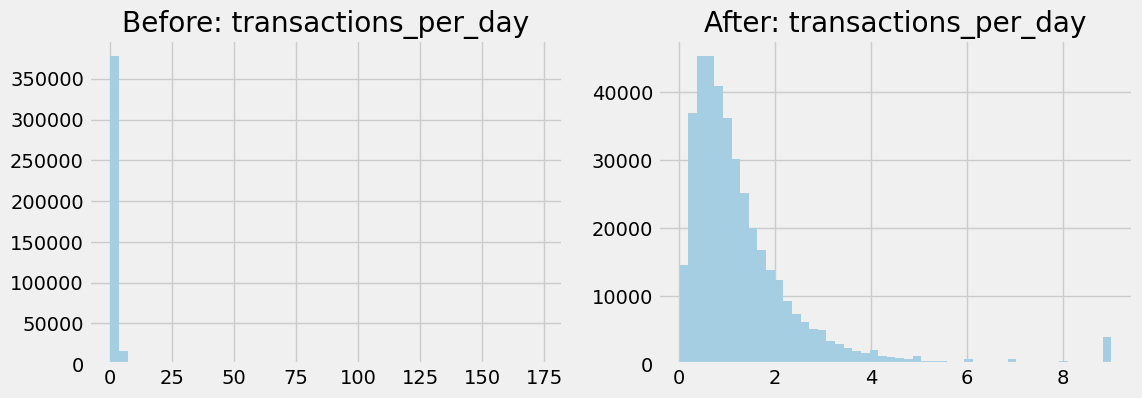

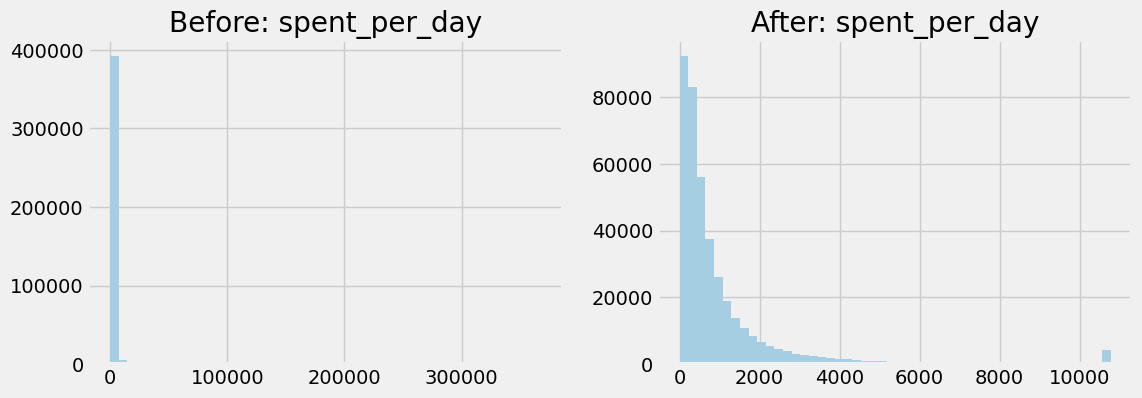

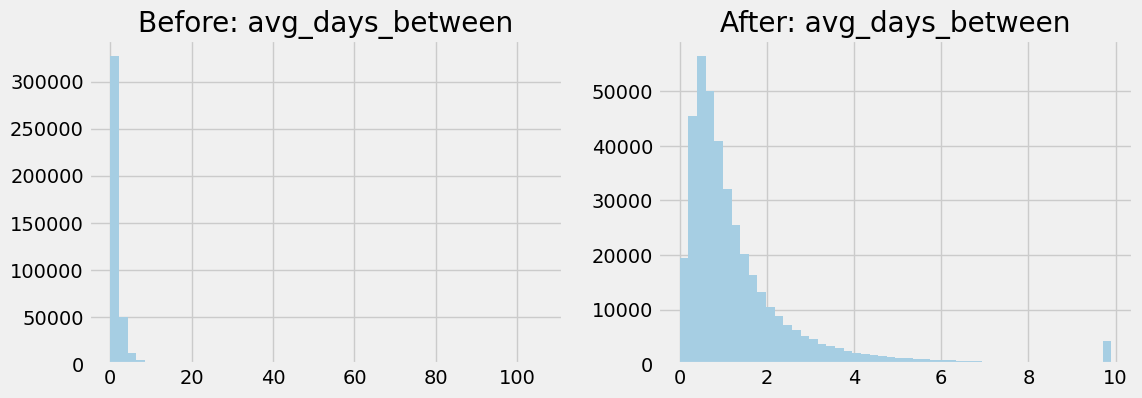

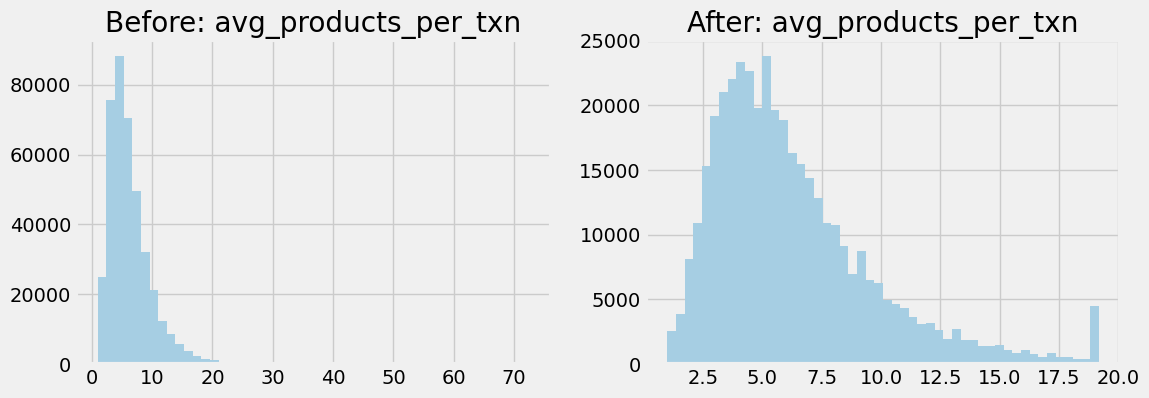

In [23]:
for col in winsor_cols:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    client_features[col].hist(bins=50, ax=axes[0])

    axes[0].set_title(
        f'Before: {col}'
    )

    client_features_winsor[col].hist(bins=50, ax=axes[1])

    axes[1].set_title(
        f'After: {col}'
    )

    plt.show()

В целом, по признакам стало значительно лучше, теперь посмотрим по `skew` насколько наши графики скошены. Если скос `skew > 1`, то просто проведём логарифмирование признаков, тем самым они будут распределены уже более похожи на нормальные.

In [49]:
skew_df = pd.DataFrame({
    'feature': numeric_cols,
    'skew': [
        client_features_winsor[col]
        .skew()
        for col in numeric_cols
    ]

})

skew_df = skew_df.sort_values(
    'skew',
    ascending=False
)

skew_df

,feature,skew
12,spent_per_day,3.713660e+00
3,total_spent,3.153823e+00
11,transactions_per_day,3.029801e+00
14,avg_days_between,2.938704e+00
4,mean_purchase,1.762297e+00
1,unique_days,1.583390e+00
0,transactions_cnt,1.576973e+00
13,avg_products_per_txn,1.357971e+00
6,unique_stores,1.338178e+00
5,unique_products,1.219537e+00


Теперь логарифмирование

In [50]:
skew_treshold = 1

log_transform_cols = skew_df[skew_df['skew'] > skew_treshold]['feature'].tolist()

print(log_transform_cols)

['spent_per_day', 'total_spent', 'transactions_per_day', 'avg_days_between', 'mean_purchase', 'unique_days', 'transactions_cnt', 'avg_products_per_txn', 'unique_stores', 'unique_products']


In [51]:
client_features_log = client_features_winsor.copy()

for col in log_transform_cols:
    client_features_log[f'log_{col}'] = np.log1p(client_features_log[col])

Теперь соединим с общими данными клиентов, предварительно их нужно обработать

In [52]:

clients = data_clients.copy()

date_cols = [
    'first_issue_date',
    'first_redeem_date'
]

for col in date_cols:
    clients[col] = pd.to_datetime(
        clients[col]
    )

reference_date = max(
    clients['first_issue_date'].max(),
    clients['first_redeem_date'].max()
)

clients['days_since_first_issue'] = (
    reference_date
    - clients['first_issue_date']
).dt.days

clients['days_since_first_redeem'] = (
    reference_date
    - clients['first_redeem_date']
).dt.days

clients['redeem_delay_days'] = (
    clients['first_redeem_date']
    - clients['first_issue_date']
).dt.days

clients['has_redeemed'] = (
    clients['first_redeem_date']
    .notna()
).astype(int)

clients['issue_month'] = (
    clients['first_issue_date']
    .dt.month
)

clients['issue_dayofweek'] = (
    clients['first_issue_date']
    .dt.dayofweek
)

clients['redeem_month'] = (
    clients['first_redeem_date']
    .dt.month
)

clients['redeem_dayofweek'] = (
    clients['first_redeem_date']
    .dt.dayofweek
)

clients = clients.drop(
    columns=[
        'first_issue_date',
        'first_redeem_date'
    ]
)

clients.head()

,client_id,age,gender,days_since_first_issue,days_since_first_redeem,redeem_delay_days,has_redeemed,issue_month,issue_dayofweek,redeem_month,redeem_dayofweek
0,000012768d,45,U,836,684.0,152.0,1,8,5,1.0,3.0
1,000036f903,72,F,953,940.0,12.0,1,4,0,4.0,6.0
2,000048b7a6,68,F,339,NaN,NaN,0,12,5,NaN,NaN
3,000073194a,60,F,910,725.0,184.0,1,5,1,11.0,4.0
4,00007c7133,67,U,911,323.0,588.0,1,5,0,12.0,0.0


In [53]:
full_features = clients.merge(
    client_features_log,
    on='client_id',
    how='left'
)

Теперь ещё раз выделим численные и категориальные признаки, которые будем использовать - это нужно будет для кодирования впоследствии, сейчас же мы заменим NaN в численных - медианой, а в категориальных - UNKNOWN, потом это просто можно закодировать будет.

In [56]:
full_features = full_features.set_index('client_id')
full_features.head()

,age,gender,days_since_first_issue,days_since_first_redeem,redeem_delay_days,has_redeemed,issue_month,issue_dayofweek,redeem_month,redeem_dayofweek,...,log_spent_per_day,log_total_spent,log_transactions_per_day,log_avg_days_between,log_mean_purchase,log_unique_days,log_transactions_cnt,log_avg_products_per_txn,log_unique_stores,log_unique_products
client_id,,,,,,,,,,,,,,,,,,,,,
000012768d,45,U,836,684.0,152.0,1,8,5,1.0,3.0,...,5.974812,10.616682,0.405465,1.105127,6.666688,1.609438,3.970292,2.639057,1.386294,3.850148
000036f903,72,F,953,940.0,12.0,1,4,0,4.0,6.0,...,6.291807,10.981319,0.910771,0.463773,5.896458,3.496508,5.093750,1.802122,1.791759,4.574711
000048b7a6,68,F,339,531.0,132.0,0,12,5,7.0,3.0,...,5.836725,10.299744,0.496937,0.927141,6.276241,2.197225,4.043051,2.079442,1.098612,3.806662
000073194a,60,F,910,725.0,184.0,1,5,1,11.0,4.0,...,6.338672,11.046450,0.553160,0.820487,6.641022,2.890372,4.418841,1.761907,0.693147,4.234107
00007c7133,67,U,911,323.0,588.0,1,5,0,12.0,0.0,...,6.283464,10.896734,0.599815,0.775064,6.479411,2.397895,4.430817,2.145400,1.098612,4.174387


In [57]:
numeric_cols = full_features.select_dtypes(include=np.number).columns
categorical_cols = full_features.select_dtypes(exclude=np.number).columns

for col in numeric_cols:
    median_value = (
        full_features[col]
        .median()
    )

    full_features[col] = (
        full_features[col]
        .fillna(median_value)
    )

for col in categorical_cols:
    full_features[col] = (
        full_features[col]
        .fillna('UNKNOWN')
    )

In [58]:
data_train = data_train.set_index('client_id')
data_train.head()

KeyError: "None of ['client_id'] are in the columns"

Закодирум теперь категориальные признаки, их всего 3, поэтому это будет не так сложно, причём для `gender` сделаем one-hot, для остальных сделаем `Label`, так как категорий очень много.

In [60]:
from sklearn.preprocessing import LabelEncoder

full_features_encoded = (
    full_features.copy()
)

full_features_encoded = pd.get_dummies(
    full_features_encoded,
    columns=['gender'],
    drop_first=True
)

label_cols = [
    'favorite_store',
    'favorite_product'
]

label_encoders = {}

for col in label_cols:

    le = LabelEncoder()

    full_features_encoded[col] = le.fit_transform(
        full_features_encoded[col].astype(str)
    )

    label_encoders[col] = le

Проверим, что все признаки числовые и нет NaN

In [61]:
full_features_encoded.info()

<class 'pandas.core.frame.DataFrame'>
Index: 400162 entries, 000012768d to fffff6ce77
Data columns (total 41 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   age                       400162 non-null  int64  
 1   days_since_first_issue    400162 non-null  int64  
 2   days_since_first_redeem   400162 non-null  float64
 3   redeem_delay_days         400162 non-null  float64
 4   has_redeemed              400162 non-null  int64  
 5   issue_month               400162 non-null  int32  
 6   issue_dayofweek           400162 non-null  int32  
 7   redeem_month              400162 non-null  float64
 8   redeem_dayofweek          400162 non-null  float64
 9   transactions_cnt          400162 non-null  int64  
 10  unique_days               400162 non-null  int64  
 11  unique_months             400162 non-null  int64  
 12  total_spent               400162 non-null  float64
 13  mean_purchase             400162 non

Теперь выделим явно X, T, Y, чтоб с ними работать, плюс разделим на трейн, валидацию и тест. Валидацию для не нейросетевых моделей не будем использовать, она нужна для подбора количества эпох в обучении нейросетей.

In [62]:
indices_train, indices_temp = train_test_split(
    data_train.index,
    test_size=0.3,
    random_state=42
)

indices_val, indices_test = train_test_split(
    indices_temp,
    test_size=0.5,
    random_state=42
)

X_train = full_features_encoded.loc[indices_train, :]
X_val   = full_features_encoded.loc[indices_val, :]
X_test  = full_features_encoded.loc[indices_test, :]

y_train = data_train.loc[indices_train, "target"]
y_val   = data_train.loc[indices_val, "target"]
y_test  = data_train.loc[indices_test, "target"]

treat_train = data_train.loc[indices_train, "treatment_flg"]
treat_val   = data_train.loc[indices_val, "treatment_flg"]
treat_test  = data_train.loc[indices_test, "treatment_flg"]

Теперь будем обучать модели, собственно, обучим 5 моделей:

1. T-Learner
2. X-Learner
3. S-Learner
4. DragonNet
5. TARNet

Будем их сравнивать по предсказанию CATE с помощью как раз отрисовки uplift-кривых и расчёта метрик.

Для начала обучим T-Learner - то есть 2 модели

In [63]:
treatment_model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.03,
    depth=6,
    loss_function='Logloss',
    eval_metric='AUC',
    random_seed=42,
    verbose=100
)

control_model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.03,
    depth=6,
    loss_function='Logloss',
    eval_metric='AUC',
    random_seed=42,
    verbose=100
)

t_learner = TwoModels(
    estimator_trmnt=treatment_model,
    estimator_ctrl=control_model,
    method='vanilla'
)

t_learner.fit(
    X=X_train,
    y=y_train,
    treatment=treat_train
)

cate_t = t_learner.predict(
    X_test
)

0:	total: 56.1ms	remaining: 28s
100:	total: 831ms	remaining: 3.28s
200:	total: 1.6s	remaining: 2.38s
300:	total: 2.35s	remaining: 1.55s
400:	total: 3.1s	remaining: 765ms
499:	total: 3.83s	remaining: 0us
0:	total: 8.98ms	remaining: 4.48s
100:	total: 770ms	remaining: 3.04s
200:	total: 1.53s	remaining: 2.27s
300:	total: 2.28s	remaining: 1.51s
400:	total: 3.02s	remaining: 747ms
499:	total: 3.75s	remaining: 0us


Теперь обучим S-Learner

In [65]:
base_model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.03,
    depth=6,
    loss_function='Logloss',
    eval_metric='AUC',
    random_seed=42,
    verbose=100
)

s_learner = SoloModel(
    estimator=base_model,
    method='treatment_interaction'
)

s_learner.fit(
    X=X_train,
    y=y_train,
    treatment=treat_train
)

cate_s = s_learner.predict(X_test)

0:	total: 16.7ms	remaining: 8.35s
100:	total: 1.52s	remaining: 6s
200:	total: 3.01s	remaining: 4.47s
300:	total: 4.5s	remaining: 2.97s
400:	total: 6.01s	remaining: 1.48s
499:	total: 7.56s	remaining: 0us


Наконец, X-Learner

In [72]:
outcome_learner = CatBoostClassifier(
    iterations=500,
    learning_rate=0.03,
    depth=6,
    loss_function='Logloss',
    eval_metric='AUC',
    random_seed=42,
    verbose=100
)

effect_learner = CatBoostRegressor(
    iterations=300,
    learning_rate=0.03,
    depth=5,
    loss_function='RMSE',
    random_seed=42,
    verbose=100
)

x_learner = BaseXClassifier(
    outcome_learner=outcome_learner,
    effect_learner=effect_learner
)

x_learner.fit(
    X=X_train.values,
    treatment=treat_train.values,
    y=y_train.values
)

cate_x = x_learner.predict(
    X_test.values
)

cate_x = cate_x.flatten()

0:	total: 9.27ms	remaining: 4.62s
100:	total: 760ms	remaining: 3s
200:	total: 1.51s	remaining: 2.25s
300:	total: 2.32s	remaining: 1.53s
400:	total: 3.13s	remaining: 773ms
499:	total: 3.94s	remaining: 0us
0:	total: 9.01ms	remaining: 4.49s
100:	total: 766ms	remaining: 3.03s
200:	total: 1.53s	remaining: 2.28s
300:	total: 2.28s	remaining: 1.51s
400:	total: 3.02s	remaining: 746ms
499:	total: 3.76s	remaining: 0us
0:	learn: 0.4295927	total: 4.8ms	remaining: 1.44s
100:	learn: 0.4281409	total: 396ms	remaining: 780ms
200:	learn: 0.4273139	total: 789ms	remaining: 389ms
299:	learn: 0.4265737	total: 1.17s	remaining: 0us
0:	learn: 0.4223263	total: 5.22ms	remaining: 1.56s
100:	learn: 0.4201734	total: 401ms	remaining: 790ms
200:	learn: 0.4192935	total: 799ms	remaining: 394ms
299:	learn: 0.4185272	total: 1.22s	remaining: 0us


Напишем имплементацию нейросетевых моделей по статье, сначала TARNet

In [73]:
class TARNet(nn.Module):
    def __init__(self, input_dim: int, hidden_dim_heads: int, hidden_dim_tail: int, dropout: float = 0.0):
        super().__init__()
        self.tail = nn.Sequential(
            nn.Linear(input_dim, hidden_dim_tail),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim_tail, hidden_dim_tail),
            nn.ReLU(),
            nn.Dropout(dropout),
        )

        self.Q0_head = nn.Sequential(
            nn.Linear(hidden_dim_tail, hidden_dim_heads),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim_heads, 1)
        )

        self.Q1_head = nn.Sequential(
            nn.Linear(hidden_dim_tail, hidden_dim_heads),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim_heads, 1)
        )

    def forward(self, x: torch.Tensor):
        z = self.tail(x)

        Q0 = self.Q0_head(z).squeeze()
        Q1 = self.Q1_head(z).squeeze()

        return Q0, Q1

    def compute_loss(self, x, t, y):
        Q0, Q1 = self.forward(x)
        Q = torch.where(t == 1, Q1, Q0)
        return F.mse_loss(Q, y), torch.tensor(0.0)

Теперь DragonNet

In [74]:
class DragonNet(nn.Module):
    def __init__(self, input_dim: int, hidden_dim_heads: int, hidden_dim_tail: int, num_layers: int, loss_type: str = 'basic', dropout: float = 0.0):
        super().__init__()

        layers = []
        layers.append(nn.Linear(input_dim, hidden_dim_tail))
        layers.append(nn.ReLU())
        layers.append(nn.Dropout(dropout))

        for _ in range(num_layers - 1):
            layers.append(nn.Linear(hidden_dim_tail, hidden_dim_tail))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))

        self.tail = nn.Sequential(*layers)

        self.propensity_head = nn.Sequential(
            nn.Linear(hidden_dim_tail, 1),
            nn.Sigmoid()
        )

        self.Q0_head = nn.Sequential(
            nn.Linear(hidden_dim_tail, hidden_dim_heads),
            nn.ReLU(),
            nn.Linear(hidden_dim_heads, hidden_dim_heads),
            nn.ReLU(),
            nn.Linear(hidden_dim_heads, 1)
        )

        self.Q1_head = nn.Sequential(
            nn.Linear(hidden_dim_tail, hidden_dim_heads),
            nn.ReLU(),
            nn.Linear(hidden_dim_heads, hidden_dim_heads),
            nn.ReLU(),
            nn.Linear(hidden_dim_heads, 1)
        )

        self.loss_type = loss_type

        if loss_type == 'targeted_reg':
            self.epsilon = nn.Parameter(torch.tensor(0.0))
        else:
            self.epsilon = None

    def forward(self, x: torch.Tensor):
        z = self.tail(x)

        propensity = self.propensity_head(z).squeeze()
        Q0 = self.Q0_head(z).squeeze()
        Q1 = self.Q1_head(z).squeeze()

        return propensity, Q0, Q1

    def compute_loss(self, x: torch.Tensor, t: torch.Tensor, y: torch.Tensor, alpha=0.1, beta=0.1):
        propensity, Q0, Q1 = self.forward(x)
        Q = torch.where(t == 1, Q1, Q0)

        eps = 1e-8
        propensity = torch.clamp(propensity, eps, 1 - eps)
        mse_loss = F.mse_loss(Q, y)

        if self.loss_type == 'basic':
            bce_loss = F.binary_cross_entropy(propensity, t.float())
            total_loss = mse_loss + alpha * bce_loss
            ret_loss = bce_loss

        elif self.loss_type == 'targeted_reg':
            bce_loss = F.binary_cross_entropy(propensity, t.float())
            H = t / (propensity + eps) - (1 - t) / (1 - propensity + eps)

            Q_tilde = Q + self.epsilon * H
            reg_loss = F.mse_loss(Q_tilde, y)
            total_loss = mse_loss + alpha * bce_loss + beta * reg_loss
            ret_loss = bce_loss

        elif self.loss_type == 'balance':
            w1 = t / (propensity + eps)
            w0 = (1 - t) / (1 - propensity + eps)
            mean1 = torch.sum(x * w1.unsqueeze(1), dim=0) / (torch.sum(w1) + eps)
            mean0 = torch.sum(x * w0.unsqueeze(1), dim=0) / (torch.sum(w0) + eps)
            bal_loss = torch.mean((mean1 - mean0) ** 2)
            ret_loss = bal_loss
            total_loss = mse_loss + alpha * bal_loss

        return total_loss, ret_loss

Теперь напишем функцию для обучения нейросетевой модели

In [75]:
from copy import deepcopy

def train_model(
    model,
    train_loader,
    val_loader,
    epochs,
    lr,
    model_name='Model',
    patience=15,
    weight_decay=1e-4,
    grad_clip=5.0
):
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='min',
        factor=0.5,
        patience=5
    )

    train_losses = []
    val_losses = []
    bce_losses = []

    best_val_loss = np.inf
    best_model_weights = None

    early_stopping_counter = 0
    for epoch in range(epochs):
        model.train()

        train_loss_epoch = 0.0
        train_bce_epoch = 0.0

        for xb, tb, yb in train_loader:
            xb = xb.to(DEVICE)
            tb = tb.to(DEVICE)
            yb = yb.to(DEVICE)

            optimizer.zero_grad()

            loss, bce_loss = model.compute_loss(
                xb,
                tb,
                yb
            )

            loss.backward()

            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                grad_clip
            )

            optimizer.step()

            train_loss_epoch += loss.item()
            train_bce_epoch += bce_loss.item()

        avg_train_loss = (
            train_loss_epoch
            / len(train_loader)
        )

        avg_train_bce = (
            train_bce_epoch
            / len(train_loader)
        )

        train_losses.append(avg_train_loss)

        model.eval()

        val_loss_epoch = 0.0
        val_bce_epoch = 0.0

        with torch.no_grad():

            for xb, tb, yb in val_loader:

                xb = xb.to(DEVICE)
                tb = tb.to(DEVICE)
                yb = yb.to(DEVICE)

                loss, bce_loss = model.compute_loss(
                    xb,
                    tb,
                    yb
                )

                val_loss_epoch += loss.item()
                val_bce_epoch += bce_loss.item()

        avg_val_loss = (
            val_loss_epoch
            / len(val_loader)
        )

        avg_val_bce = (
            val_bce_epoch
            / len(val_loader)
        )

        val_losses.append(avg_val_loss)
        bce_losses.append(avg_val_bce)

        scheduler.step(avg_val_loss)

        current_lr = (
            optimizer.param_groups[0]['lr']
        )

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_model_weights = deepcopy(
                model.state_dict()
            )
            early_stopping_counter = 0
        else:
            early_stopping_counter += 1

        print(

            f"{model_name} | "
            f"Epoch {epoch+1:03d} | "
            f"LR: {current_lr:.6f} | "
            f"Train Loss: {avg_train_loss:.4f} | "
            f"Train BCE: {avg_train_bce:.4f} | "
            f"Val Loss: {avg_val_loss:.4f} | "
            f"Val BCE: {avg_val_bce:.4f}"

        )
        if early_stopping_counter >= patience:
            print(
                f"\nEarly stopping triggered "
                f"at epoch {epoch+1}"
            )
            break

    if best_model_weights is not None:
        model.load_state_dict(
            best_model_weights
        )

        print(
            f"\nBest model restored "
            f"with val_loss={best_val_loss:.4f}"
        )

    history = {
        'train_losses': train_losses,
        'val_losses': val_losses,
        'bce_losses': bce_losses
    }

    return model, history

Отмасштабируем данные для обучения

In [76]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

Зададим датасеты для обучения и параметры

In [79]:
train_dataset = TensorDataset(
    torch.tensor(X_train, dtype=torch.float32),
    torch.tensor(treat_train, dtype=torch.float32),
    torch.tensor(y_train, dtype=torch.float32)
)
val_dataset = TensorDataset(
    torch.tensor(X_val, dtype=torch.float32),
    torch.tensor(treat_val, dtype=torch.float32),
    torch.tensor(y_val, dtype=torch.float32)
)

dragonnet = DragonNet(
    input_dim=X_train.shape[1],
    hidden_dim_heads=64,
    hidden_dim_tail=128,
    num_layers=2,
    loss_type='balance',
    dropout=0.1
).to(DEVICE)

tarnet = TARNet(X_train.shape[1], hidden_dim_tail=128, hidden_dim_heads=64,  dropout=0.1).to(DEVICE)

Обучим TARNet

In [80]:
batch_size = 128
lr = 1e-3
epochs = 200

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

_, _ = train_model(tarnet, train_loader, val_loader, epochs, lr, model_name='TARNet')

TARNet | Epoch 001 | LR: 0.001000 | Train Loss: 0.1963 | Train BCE: 0.0000 | Val Loss: 0.1894 | Val BCE: 0.0000
TARNet | Epoch 002 | LR: 0.001000 | Train Loss: 0.1876 | Train BCE: 0.0000 | Val Loss: 0.1857 | Val BCE: 0.0000
TARNet | Epoch 003 | LR: 0.001000 | Train Loss: 0.1864 | Train BCE: 0.0000 | Val Loss: 0.1850 | Val BCE: 0.0000
TARNet | Epoch 004 | LR: 0.001000 | Train Loss: 0.1855 | Train BCE: 0.0000 | Val Loss: 0.1859 | Val BCE: 0.0000
TARNet | Epoch 005 | LR: 0.001000 | Train Loss: 0.1852 | Train BCE: 0.0000 | Val Loss: 0.1853 | Val BCE: 0.0000
TARNet | Epoch 006 | LR: 0.001000 | Train Loss: 0.1849 | Train BCE: 0.0000 | Val Loss: 0.1850 | Val BCE: 0.0000
TARNet | Epoch 007 | LR: 0.001000 | Train Loss: 0.1846 | Train BCE: 0.0000 | Val Loss: 0.1848 | Val BCE: 0.0000
TARNet | Epoch 008 | LR: 0.001000 | Train Loss: 0.1843 | Train BCE: 0.0000 | Val Loss: 0.1849 | Val BCE: 0.0000
TARNet | Epoch 009 | LR: 0.001000 | Train Loss: 0.1840 | Train BCE: 0.0000 | Val Loss: 0.1848 | Val BCE:

Обучим DragonNet

In [81]:
batch_size = 64
lr = 5e-4
epochs = 200

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

_, _ = train_model(dragonnet, train_loader, val_loader, epochs, lr, model_name='DragonNet')

DragonNet | Epoch 001 | LR: 0.000500 | Train Loss: 0.2030 | Train BCE: 0.1123 | Val Loss: 0.1927 | Val BCE: 0.0641
DragonNet | Epoch 002 | LR: 0.000500 | Train Loss: 0.1930 | Train BCE: 0.0728 | Val Loss: 0.1957 | Val BCE: 0.0643
DragonNet | Epoch 003 | LR: 0.000500 | Train Loss: 0.1913 | Train BCE: 0.0640 | Val Loss: 0.1914 | Val BCE: 0.0633
DragonNet | Epoch 004 | LR: 0.000500 | Train Loss: 0.1911 | Train BCE: 0.0659 | Val Loss: 0.1921 | Val BCE: 0.0645
DragonNet | Epoch 005 | LR: 0.000500 | Train Loss: 0.1900 | Train BCE: 0.0632 | Val Loss: 0.1911 | Val BCE: 0.0635
DragonNet | Epoch 006 | LR: 0.000500 | Train Loss: 0.1898 | Train BCE: 0.0639 | Val Loss: 0.1908 | Val BCE: 0.0632
DragonNet | Epoch 007 | LR: 0.000500 | Train Loss: 0.1895 | Train BCE: 0.0634 | Val Loss: 0.1915 | Val BCE: 0.0635
DragonNet | Epoch 008 | LR: 0.000500 | Train Loss: 0.1892 | Train BCE: 0.0633 | Val Loss: 0.1914 | Val BCE: 0.0633
DragonNet | Epoch 009 | LR: 0.000500 | Train Loss: 0.1889 | Train BCE: 0.0635 | 

Теперь посчитаем метрики на тесте

In [82]:
dragonnet.eval()
tarnet.eval()
with torch.no_grad():
    X_test_t = torch.tensor(X_test, dtype=torch.float32).to(DEVICE)
    _, Q0, Q1 = dragonnet.forward(X_test_t)
    Q0_tar, Q1_tar = tarnet.forward(X_test_t)
    Q0 = Q0.cpu().numpy()
    Q1 = Q1.cpu().numpy()
    Q0_tar = Q0_tar.cpu().numpy()
    Q1_tar = Q1_tar.cpu().numpy()

dragonnet_tau = Q1 - Q0
tarnet_tau = Q1_tar - Q0_tar

Теперь сравнение моделей

,model,qini_auc,uplift_auc,uplift_at_30
2,T-Learner,0.019289,0.028170,0.072834
0,X-Learner,0.018509,0.026966,0.075279
3,DragonNet,0.009874,0.014837,0.057629
1,S-Learner,0.006401,0.009491,0.048402
4,TARNet,0.004973,0.007303,0.050785


<Figure size 1000x700 with 0 Axes>

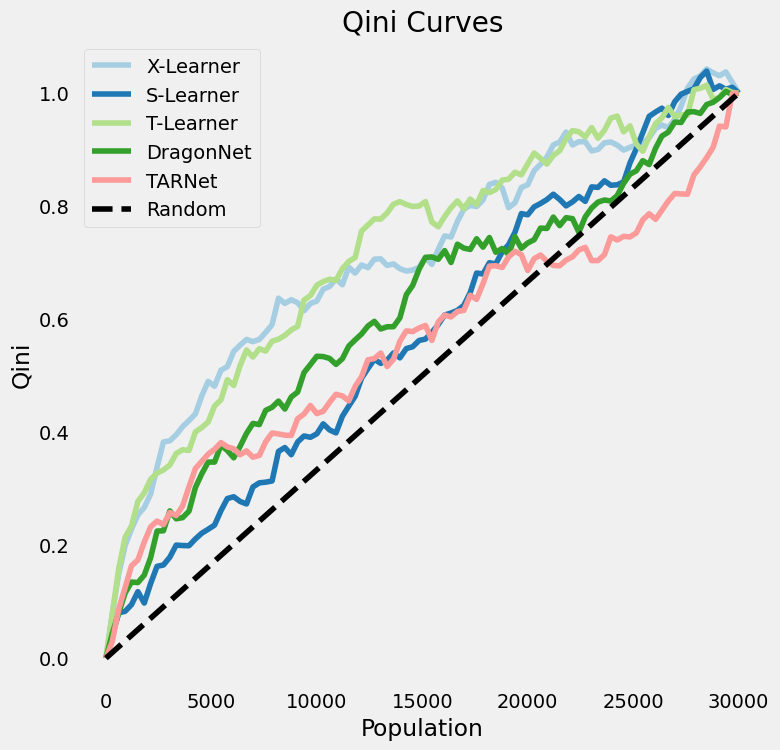

<Figure size 1000x700 with 0 Axes>

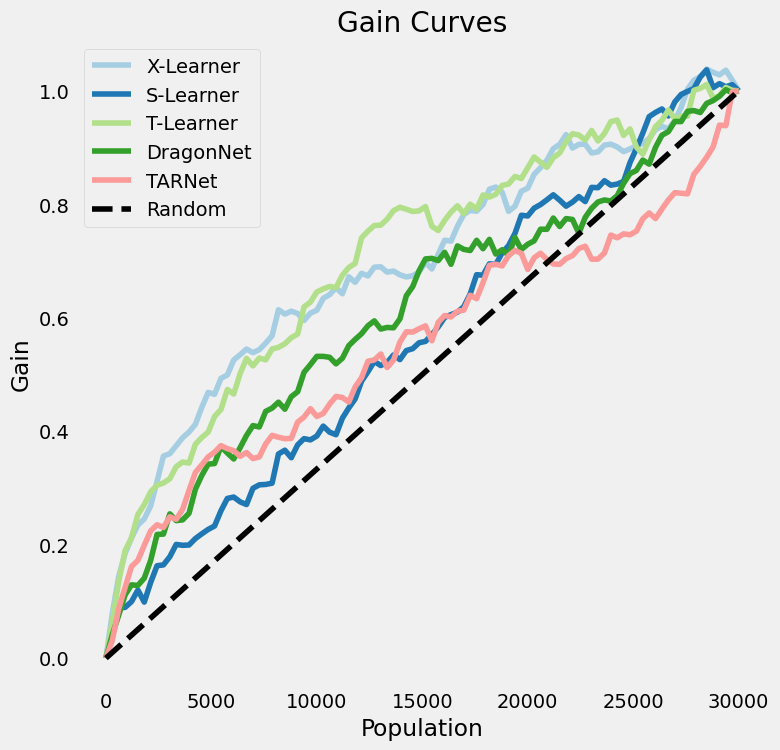

In [84]:
eval_df = pd.DataFrame({
    'outcome': y_test.values,
    'treatment': treat_test.values,
    'X-Learner': cate_x,
    'S-Learner': cate_s,
    'T-Learner': cate_t,
    'DragonNet': dragonnet_tau,
    'TARNet': tarnet_tau
})

metrics = []

model_cols = [
    'X-Learner',
    'S-Learner',
    'T-Learner',
    'DragonNet',
    'TARNet'
]

for col in model_cols:
    preds = eval_df[col]

    qini = qini_auc_score(
        y_true=eval_df['outcome'],
        uplift=preds,
        treatment=eval_df['treatment']
    )

    uplift_auc = uplift_auc_score(
        y_true=eval_df['outcome'],
        uplift=preds,
        treatment=eval_df['treatment']
    )

    uplift30 = uplift_at_k(
        y_true=eval_df['outcome'],
        uplift=preds,
        treatment=eval_df['treatment'],
        strategy='overall',
        k=0.30
    )

    metrics.append({
        'model': col,
        'qini_auc': qini,
        'uplift_auc': uplift_auc,
        'uplift_at_30': uplift30
    })

metrics_df = pd.DataFrame(metrics)

metrics_df = metrics_df.sort_values(
    'qini_auc',
    ascending=False
)

display(metrics_df)
plt.figure(figsize=(10, 7))

plot_qini(
    eval_df,
    outcome_col='outcome',
    treatment_col='treatment',
    normalize=True
)

plt.title('Qini Curves')
plt.grid()
plt.show()

plt.figure(figsize=(10, 7))

plot_gain(
    eval_df,
    outcome_col='outcome',
    treatment_col='treatment',
    normalize=True
)

plt.title('Gain Curves')
plt.grid()
plt.show()

В целом, можно увидеть, что получилось достаточно неплохое качество у `T-Learner` и `X-Learner`. У нейросетевых получилось значительно хуже качество, чем у других моделей.